# Project 1 Edge Detection

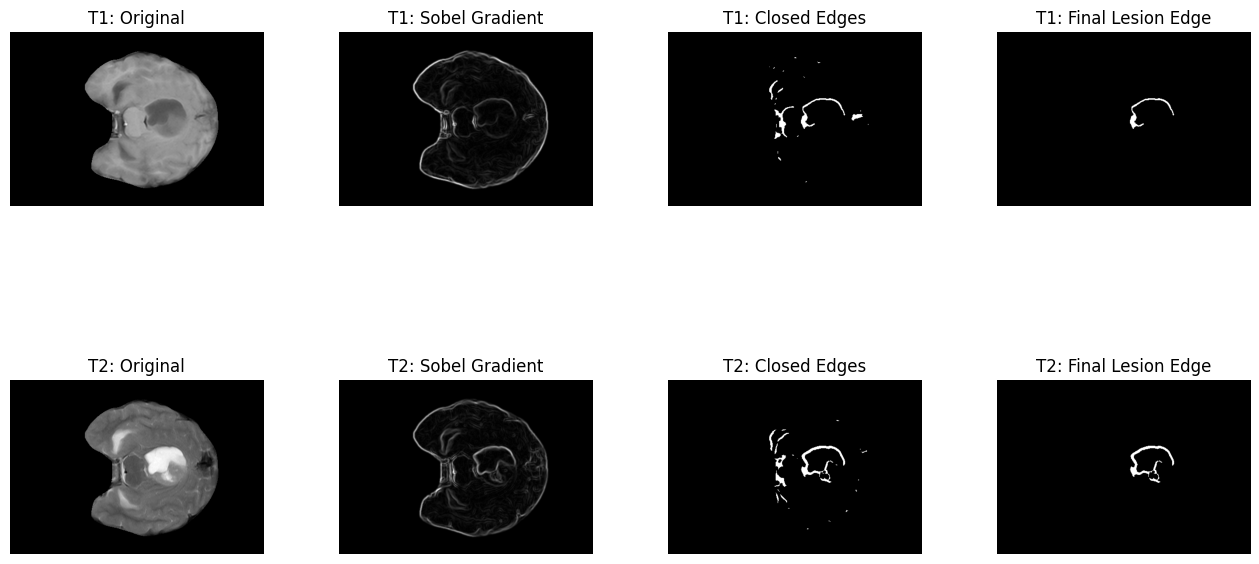

In [81]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import os

def apply_sobel_kernel(image):
    """
    实现 Sobel 梯度核计算
    """
    Kx = np.array([[-1, 0, 1], 
                   [-2, 0, 2], 
                   [-1, 0, 1]], dtype=np.float32)
    
    Ky = np.array([[-1, -2, -1], 
                   [ 0,  0,  0], 
                   [ 1,  2,  1]], dtype=np.float32)
    
    Gx = convolve2d(image, Kx, mode='same', boundary='symm')
    Gy = convolve2d(image, Ky, mode='same', boundary='symm')
    
    magnitude = np.sqrt(Gx**2 + Gy**2)
    
    if magnitude.max() > 0:
        magnitude = (magnitude / magnitude.max()) * 255
        
    return magnitude.astype(np.uint8)

def segment_lesion_edge_only(img, threshold_T):
    # 1. 5x5 平滑滤波器
    img_smooth = cv2.GaussianBlur(img, (5, 5), 0)
    
    # 2. Sobel 滤波器
    grad_mag = apply_sobel_kernel(img_smooth)
    
    # 3. 阈值 T
    _, edge_mask = cv2.threshold(grad_mag, threshold_T, 255, cv2.THRESH_BINARY)
    
    # 4. 去除大脑外围边缘
    # 获取大脑主体区域，用较大的核进行腐蚀，彻底排除头骨和皮层边缘
    _, brain_mask = cv2.threshold(img_smooth, 20, 255, cv2.THRESH_BINARY)
    kernel_erode = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
    brain_core = cv2.erode(brain_mask, kernel_erode, iterations=1)
    
    internal_edges = cv2.bitwise_and(edge_mask, brain_core)
    
    # 5. 闭运算
    # 注意：这里缩小了闭运算的核 (5x5 或 7x7)，为了连接断点，同时防止边缘线糊成一团厚厚的面
    kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
    closed_edges = cv2.morphologyEx(internal_edges, cv2.MORPH_CLOSE, kernel_close)
    
    # 6. 连通域处理 (提取病灶边缘环)
    # 对线段进行连通域分析
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(closed_edges, connectivity=8)
    
    lesion_edge_mask = np.zeros_like(img)
    valid_labels = []
    
    for i in range(1, num_labels): # 跳过背景(0)
        area = stats[i, cv2.CC_STAT_AREA] # 这里的 area 实际上是这条“线”包含的像素个数
        # 过滤掉细碎的短线(噪点)，保留较长的边缘线
        if 150 < area < 3000:
            valid_labels.append(i)
            
    if valid_labels:
        # 在符合长度的边缘线中，取像素最多(最长/最完整)的那条作为病灶轮廓
        best_label = max(valid_labels, key=lambda x: stats[x, cv2.CC_STAT_AREA])
        lesion_edge_mask[labels == best_label] = 255
        
    return grad_mag, closed_edges, lesion_edge_mask

def main():
    if not (os.path.exists('T1.npy') and os.path.exists('T2.npy')):
        print("请确保 T1.npy 和 T2.npy 在当前目录下。")
        return

    img_t1 = np.load('T1.npy')
    img_t2 = np.load('T2.npy')
    
    img_t1 = cv2.normalize(img_t1, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    img_t2 = cv2.normalize(img_t2, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 阈值可根据实际效果微调
    T1_THRESHOLD = 45
    T2_THRESHOLD = 55 

    t1_grad, t1_edges, t1_lesion = segment_lesion_edge_only(img_t1, T1_THRESHOLD)
    t2_grad, t2_edges, t2_lesion = segment_lesion_edge_only(img_t2, T2_THRESHOLD)

    # ================= 结果可视化 =================
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)
    
    titles = ['Original', 'Sobel Gradient', 'Closed Edges', 'Final Lesion Edge']
    
    images_t1 = [img_t1, t1_grad, t1_edges, t1_lesion]
    for i in range(4):
        axes[0, i].imshow(images_t1[i], cmap='gray')
        axes[0, i].set_title(f'T1: {titles[i]}')
        axes[0, i].axis('off')
        
    images_t2 = [img_t2, t2_grad, t2_edges, t2_lesion]
    for i in range(4):
        axes[1, i].imshow(images_t2[i], cmap='gray')
        axes[1, i].set_title(f'T2: {titles[i]}')
        axes[1, i].axis('off')

    plt.show()

if __name__ == "__main__":
    main()

# Project 2 Thresholding

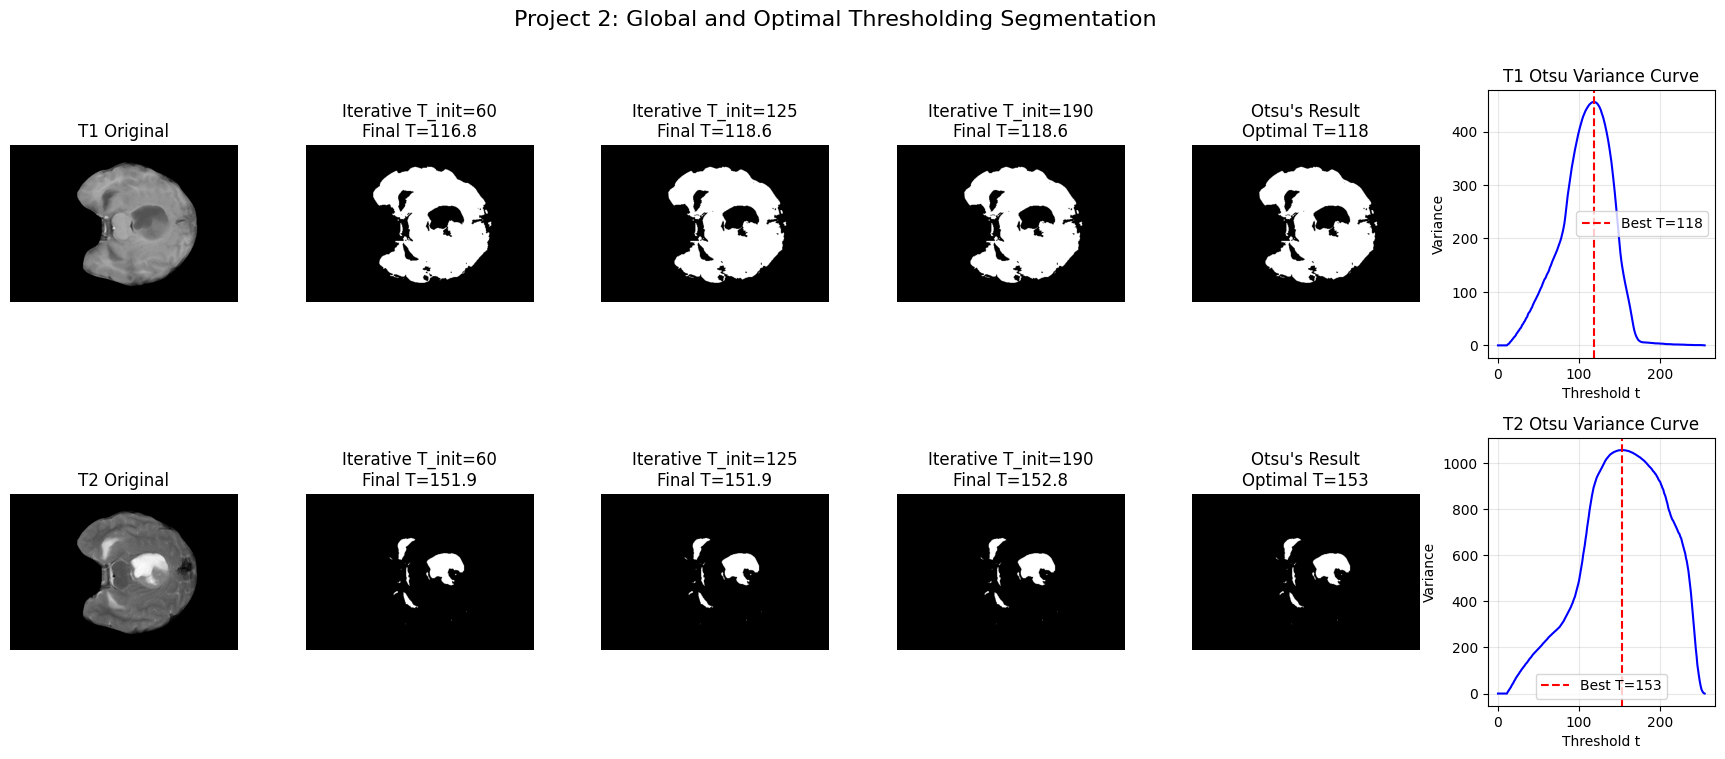

In [93]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

def iterative_threshold_manual(image, initial_T, delta=0.5):
    """
    实现迭代全局阈值分割
    """
    # 排除背景像素(<=10)，仅对脑组织进行计算
    pixels = image[image > 10].astype(np.float32)
    if len(pixels) == 0: return 0
    
    T = float(initial_T)
    while True:
        # 分为两类
        g1 = pixels[pixels > T]
        g2 = pixels[pixels <= T]
        
        # 计算均值
        mu1 = np.mean(g1) if len(g1) > 0 else 0
        mu2 = np.mean(g2) if len(g2) > 0 else 0
        
        T_new = (mu1 + mu2) / 2.0
        
        # 判断收敛
        if abs(T - T_new) < delta:
            break
        T = T_new
    return T

def otsu_threshold_manual(image):
    """
    手动实现 Otsu 最优阈值算法，并返回方差曲线
    """
    # 排除背景像素，只统计脑组织部分
    brain_pixels = image[image > 10]
    total_pixels = brain_pixels.size
    
    # 计算直方图
    hist = np.histogram(brain_pixels, bins=256, range=(0, 256))[0]
    
    variances = np.zeros(256)
    max_variance = -1
    best_T = 0
    
    # 遍历所有可能的阈值 t
    for t in range(1, 255):
        # 计算 w0, w1 (类概率权重)
        w0 = np.sum(hist[:t]) / total_pixels
        w1 = np.sum(hist[t:]) / total_pixels
        
        if w0 == 0 or w1 == 0:
            continue
            
        # 计算 mu0, mu1 (类平均灰度)
        mu0 = np.sum(np.arange(t) * hist[:t]) / (w0 * total_pixels)
        mu1 = np.sum(np.arange(t, 256) * hist[t:]) / (w1 * total_pixels)
        
        # 计算类间方差 sigma_b^2
        variance = w0 * w1 * ((mu0 - mu1) ** 2)
        variances[t] = variance
        
        if variance > max_variance:
            max_variance = variance
            best_T = t
            
    return best_T, variances

def main():
    # 检查数据
    if not (os.path.exists('T1.npy') and os.path.exists('T2.npy')):
        print("请确保数据文件 T1.npy 和 T2.npy 在当前目录下。")
        return

    # 加载并归一化到 0-255
    img_t1 = cv2.normalize(np.load('T1.npy'), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    img_t2 = cv2.normalize(np.load('T2.npy'), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 设定三个不同的初始 T 值
    initial_Ts = [60, 125, 190]
    
    # 绘图设置：2行(T1, T2) x 6列(原图, 3个迭代结果, Otsu结果, 方差曲线)
    fig, axes = plt.subplots(2, 6, figsize=(22, 8))
    plt.subplots_adjust(wspace=0.3, hspace=0.3)

    for row, img, label in zip([0, 1], [img_t1, img_t2], ['T1', 'T2']):
        # 1. 原始图像
        axes[row, 0].imshow(img, cmap='gray')
        axes[row, 0].set_title(f"{label} Original")
        
        # 2. 迭代法：三个不同的初始 T 值
        for i, t_init in enumerate(initial_Ts):
            t_final = iterative_threshold_manual(img, t_init)
            _, bin_img = cv2.threshold(img, t_final, 255, cv2.THRESH_BINARY)
            axes[row, i+1].imshow(bin_img, cmap='gray')
            axes[row, i+1].set_title(f"Iterative T_init={t_init}\nFinal T={t_final:.1f}")
        
        # 3. Otsu 法结果
        otsu_t, variances = otsu_threshold_manual(img)
        _, otsu_bin = cv2.threshold(img, otsu_t, 255, cv2.THRESH_BINARY)
        axes[row, 4].imshow(otsu_bin, cmap='gray')
        axes[row, 4].set_title(f"Otsu's Result\nOptimal T={otsu_t}")
        
        # 4. Otsu 类间方差曲线
        axes[row, 5].plot(variances, color='blue', linewidth=1.5)
        axes[row, 5].axvline(otsu_t, color='red', linestyle='--', label=f'Best T={otsu_t}')
        axes[row, 5].set_title(f"{label} Otsu Variance Curve")
        axes[row, 5].set_xlabel("Threshold t")
        axes[row, 5].set_ylabel("Variance")
        axes[row, 5].legend()
        axes[row, 5].grid(True, alpha=0.3)

    # 隐藏图像部分的坐标轴
    for ax in axes[:, :5].flatten():
        ax.axis('off')

    plt.suptitle("Project 2: Global and Optimal Thresholding Segmentation", fontsize=16)
    plt.show()

if __name__ == "__main__":
    main()

# Project3 Segmentation

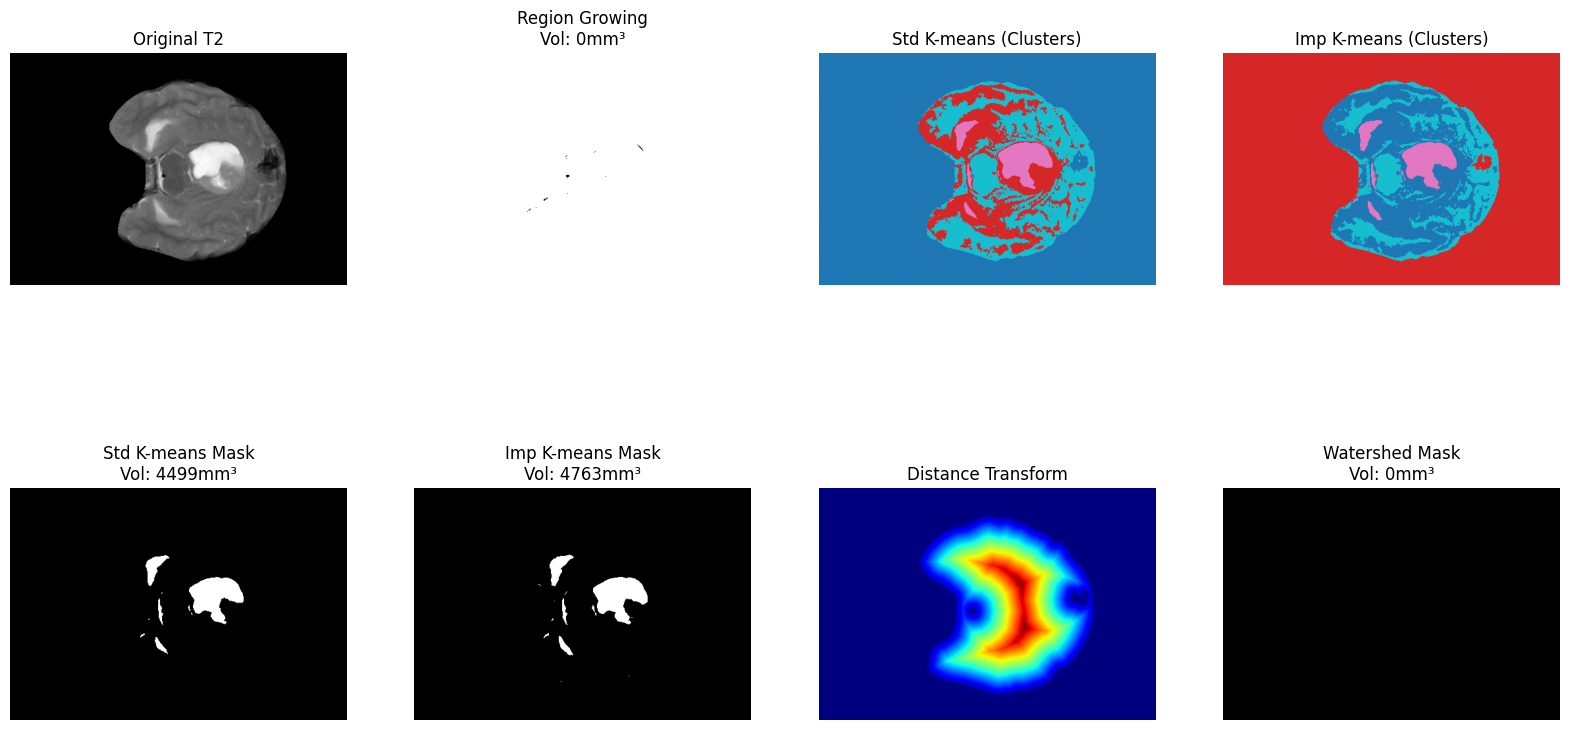

各算法病灶体积统计 (mm³):
Region Growing: 0
Standard K-means: 4499
Improved K-means: 4763
Watershed: 0


In [109]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

def main():
    if not os.path.exists('T2.npy'):
        print("未找到 T2.npy")
        return
        
    # 1. 加载数据并进行标准化预处理
    raw_img = np.load('T2.npy')
    img = cv2.normalize(raw_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    h, w = img.shape

    # ==========================================
    # 1. 区域生长 (Region Growing - 库函数调用)
    # ==========================================
    # 采用重度模糊后的最亮点作为种子，确保点在病灶中心
    blur_for_seed = cv2.medianBlur(img, 15)
    _, _, _, seed_loc = cv2.minMaxLoc(blur_for_seed)
    
    # 建立 mask (h+2, w+2)
    rg_temp_mask = np.zeros((h + 2, w + 2), np.uint8)
    # loDiff/upDiff 需要根据 T2 图像的对比度调整，通常 20-30 比较合适
    cv2.floodFill(img.copy(), rg_temp_mask, seed_loc, 255, (25,), (25,), cv2.FLOODFILL_MASK_ONLY)
    mask_rg = rg_temp_mask[1:-1, 1:-1]

    # ==========================================
    # 2. 标准 K-means (Standard K-means)
    # ==========================================
    K = 4 # 分为：背景、脑脊液、脑组织、病灶
    data_std = img.reshape((-1, 1)).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    _, labels_std, _ = cv2.kmeans(data_std, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    labels_std = labels_std.reshape(img.shape)

    # ==========================================
    # 3. 改进的 K-means (Improved K-means)
    # ==========================================
    # 核心修正：空间权重必须非常小 (如 0.05)，否则坐标会主导聚类产生条纹
    spatial_w = 0.05 
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    
    # 特征归一化
    feat_gray = img.flatten() / 255.0
    feat_x = (x.flatten() / w) * spatial_w
    feat_y = (y.flatten() / h) * spatial_w
    
    data_imp = np.stack([feat_gray, feat_x, feat_y], axis=1).astype(np.float32)
    _, labels_imp, _ = cv2.kmeans(data_imp, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    labels_imp = labels_imp.reshape(img.shape)

    # 提取病灶 Mask (取均值最高的类)
    def extract_lesion(labels, original):
        means = [np.mean(original[labels == i]) for i in range(K)]
        idx = np.argmax(means)
        mask = np.zeros_like(original)
        mask[labels == idx] = 255
        return mask

    mask_std_final = extract_lesion(labels_std, img)
    mask_imp_final = extract_lesion(labels_imp, img)

    # ==========================================
    # 4. 距离变换分水岭 (Watershed)
    # ==========================================
    # 预处理：只在脑部区域内做分水岭
    _, brain_mask = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)
    dist = cv2.distanceTransform(brain_mask, cv2.DIST_L2, 5)
    
    # 找到确定的前景（病灶核心）
    # 在 T2 图像中，病灶往往是距离边缘较远且亮度高的区域
    _, sure_fg = cv2.threshold(dist, 0.6 * dist.max(), 255, 0)
    sure_fg = np.uint8(sure_fg)
    
    # 标记连通域
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    # 确定未知区域 (边界)
    unknown = cv2.subtract(brain_mask, sure_fg)
    markers[unknown == 0] = 0 # 背景和未知区域处理
    
    # 实施分水岭
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    markers_res = cv2.watershed(img_color, markers)
    mask_water = np.zeros_like(img)
    # 通常标签 2 或以上是检测到的目标块
    mask_water[markers_res > 1] = 255

    # ==========================================
    # 5. 体积计算 (1mm x 1mm)
    # ==========================================
    results = {
        "Region Growing": mask_rg,
        "Standard K-means": mask_std_final,
        "Improved K-means": mask_imp_final,
        "Watershed": mask_water
    }
    
    volumes = {k: np.sum(v == 255) for k, v in results.items()}

    # ==========================================
    # 可视化排版
    # ==========================================
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    plt.subplots_adjust(wspace=0.2, hspace=0.3)
    
    # 第一行：基础算法
    axes[0,0].imshow(img, cmap='gray'); axes[0,0].set_title("Original T2")
    axes[0,1].imshow(mask_rg, cmap='gray'); axes[0,1].set_title(f"Region Growing\nVol: {volumes['Region Growing']}mm³")
    axes[0,2].imshow(labels_std, cmap='tab10'); axes[0,2].set_title("Std K-means (Clusters)")
    axes[0,3].imshow(labels_imp, cmap='tab10'); axes[0,3].set_title("Imp K-means (Clusters)")
    
    # 第二行：提取结果对比
    axes[1,0].imshow(mask_std_final, cmap='gray'); axes[1,0].set_title(f"Std K-means Mask\nVol: {volumes['Standard K-means']}mm³")
    axes[1,1].imshow(mask_imp_final, cmap='gray'); axes[1,1].set_title(f"Imp K-means Mask\nVol: {volumes['Improved K-means']}mm³")
    axes[1,2].imshow(dist, cmap='jet'); axes[1,2].set_title("Distance Transform")
    axes[1,3].imshow(mask_water, cmap='gray'); axes[1,3].set_title(f"Watershed Mask\nVol: {volumes['Watershed']}mm³")

    for ax in axes.flatten(): ax.axis('off')
    plt.show()

    print("各算法病灶体积统计 (mm³):")
    for k, v in volumes.items(): print(f"{k}: {v}")

if __name__ == "__main__":
    main()


[坐标锁定] 种子点: X=305, Y=159

开始测试不同的 K-means 参数组合...


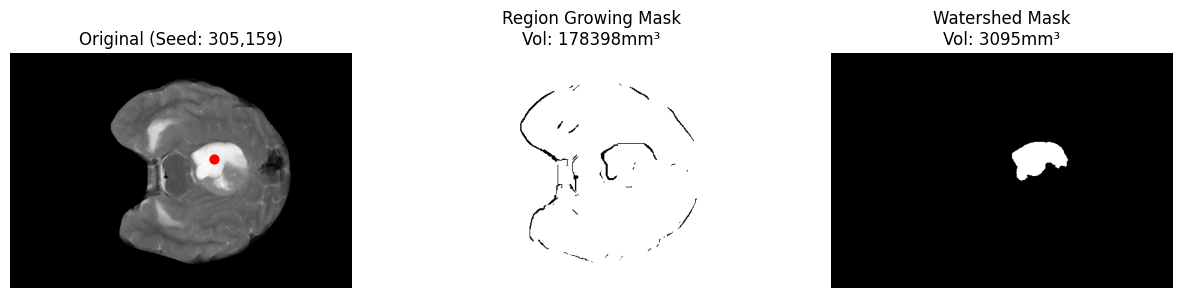

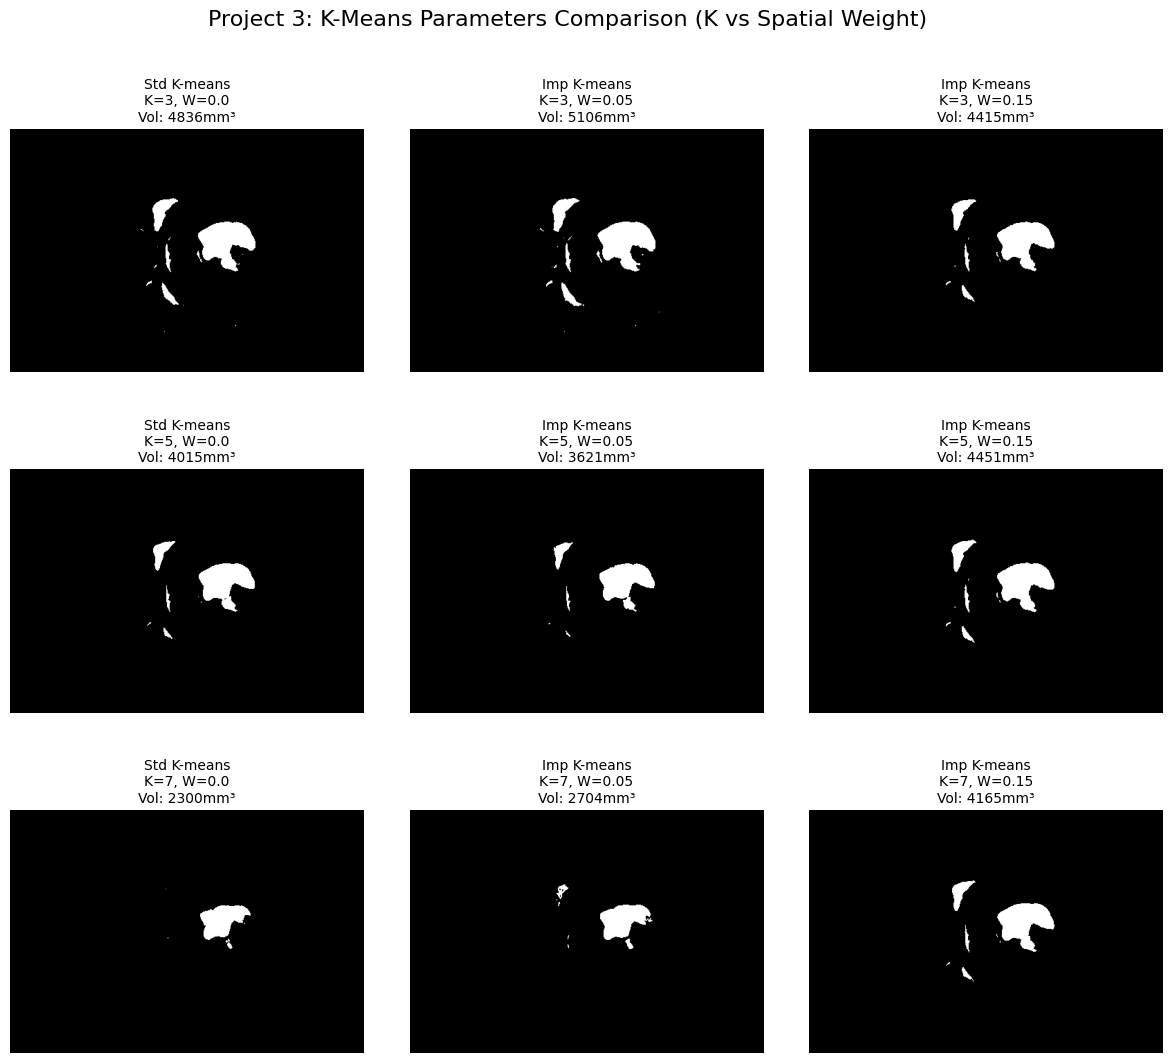

In [118]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# 全局变量存储种子点
seed_point = None

def mouse_callback(event, x, y, flags, param):
    global seed_point
    if event == cv2.EVENT_LBUTTONDOWN:
        seed_point = (x, y)
        print(f"\n[坐标锁定] 种子点: X={x}, Y={y}")
        cv2.destroyAllWindows()

def get_lesion_by_seed(labels, sx, sy):
    """根据点击的种子点，提取对应的聚类掩膜"""
    target_label = labels[sy, sx]
    mask = np.zeros_like(labels, dtype=np.uint8)
    mask[labels == target_label] = 255
    return mask

def main():
    global seed_point
    if not os.path.exists('T2.npy'):
        print("错误：未找到 T2.npy")
        return
        
    raw_img = np.load('T2.npy')
    img = cv2.normalize(raw_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    h, w = img.shape

    # 1. 交互式获取种子点
    # seed_point = (305, 161) # 你也可以直接取消注释，固定使用你上次点好的坐标
    if seed_point is None:
        cv2.imshow("CLICK LESION CENTER", img)
        cv2.setMouseCallback("CLICK LESION CENTER", mouse_callback)
        cv2.waitKey(0)
    if seed_point is None: return
    seed_x, seed_y = seed_point

    # ==========================================
    # 模块 A: 区域生长 (修复底层 Bug 与溢出)
    # ==========================================
    # 1. 先进行高斯模糊，阻断细小的噪点桥梁
    blur_img = cv2.GaussianBlur(img, (5, 5), 0)
    ff_mask = np.zeros((h + 2, w + 2), np.uint8)
    
    # 【核心修复】：(255 << 8) 强制要求 OpenCV 把掩膜填充为 255 而不是 1
    flags = 4 | (255 << 8) | cv2.FLOODFILL_MASK_ONLY
    
    # 降低容忍度至 12 (loDiff和upDiff)，防止水流溢出
    cv2.floodFill(blur_img, ff_mask, (seed_x, seed_y), 0, (8,), (8,), flags)
    mask_rg = ff_mask[1:-1, 1:-1]

    # ==========================================
    # 模块 B: 分水岭算法 
    # ==========================================
    _, brain_mask = cv2.threshold(img, 15, 255, cv2.THRESH_BINARY)
    markers = np.zeros(img.shape, dtype=np.int32)
    markers[brain_mask == 0] = 1                 # 背景种子
    cv2.circle(markers, (seed_x, seed_y), 3, 2, -1) # 前景(病灶)种子
    
    gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, np.ones((3,3)))
    res_markers = cv2.watershed(cv2.cvtColor(gradient, cv2.COLOR_GRAY2BGR), markers)
    mask_water = np.zeros_like(img)
    mask_water[res_markers == 2] = 255

    # ==========================================
    # 模块 C: K-Means 参数对比网格 (响应 PPT 要求)
    # ==========================================
    # 设置我们要测试的 K 值和 空间权重 (Weight)
    K_list = [3, 5, 7]
    W_list = [0.0, 0.05, 0.15]  # W=0.0 就是 Standard K-means
    
    kmeans_results = {}
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    x_grid, y_grid = np.meshgrid(np.arange(w), np.arange(h))
    
    print("\n开始测试不同的 K-means 参数组合...")
    for K in K_list:
        for W in W_list:
            data = np.stack([
                img.flatten() / 255.0, 
                (x_grid.flatten() / w) * W, 
                (y_grid.flatten() / h) * W
            ], axis=1).astype(np.float32)
            
            _, labels, _ = cv2.kmeans(data, K, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
            labels = labels.reshape(img.shape)
            mask = get_lesion_by_seed(labels, seed_x, seed_y)
            
            kmeans_results[(K, W)] = {
                'labels': labels,
                'mask': mask,
                'vol': np.sum(mask == 255)
            }

    # ==========================================
    # 可视化 1: 基础算法总结 (区域生长 & 分水岭)
    # ==========================================
    fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
    fig1.canvas.manager.set_window_title('Basic Segmentations')
    
    axes1[0].imshow(img, cmap='gray')
    axes1[0].scatter(seed_x, seed_y, c='red', s=40)
    axes1[0].set_title(f"Original (Seed: {seed_x},{seed_y})")
    
    axes1[1].imshow(mask_rg, cmap='gray')
    axes1[1].set_title(f"Region Growing Mask\nVol: {np.sum(mask_rg == 255)}mm³")
    
    axes1[2].imshow(mask_water, cmap='gray')
    axes1[2].set_title(f"Watershed Mask\nVol: {np.sum(mask_water == 255)}mm³")
    
    for ax in axes1: ax.axis('off')

    # ==========================================
    # 可视化 2: K-Means 组合测试对比图表
    # ==========================================
    fig2, axes2 = plt.subplots(len(K_list), len(W_list), figsize=(15, 12))
    fig2.canvas.manager.set_window_title('K-Means Parameter Search')
    plt.subplots_adjust(wspace=0.1, hspace=0.4)
    
    for i, K in enumerate(K_list):
        for j, W in enumerate(W_list):
            res = kmeans_results[(K, W)]
            ax = axes2[i, j]
            
            # W=0 时是标准 K-means，W>0 是改进 K-means
            alg_name = "Std K-means" if W == 0 else "Imp K-means"
            ax.imshow(res['mask'], cmap='gray')
            ax.set_title(f"{alg_name}\nK={K}, W={W}\nVol: {res['vol']}mm³", fontsize=10)
            ax.axis('off')

    plt.suptitle("Project 3: K-Means Parameters Comparison (K vs Spatial Weight)", fontsize=16)
    

    plt.show()

if __name__ == "__main__":
    main()

>>> 请在弹出窗口点击病灶中心...
>>> 正在运行区域生长，请在弹出窗口通过滑动条调整容忍度 (Tolerance)...
>>> 正在进行 K-Means 多参数对比测试...

[完成] 请查看对比图表。


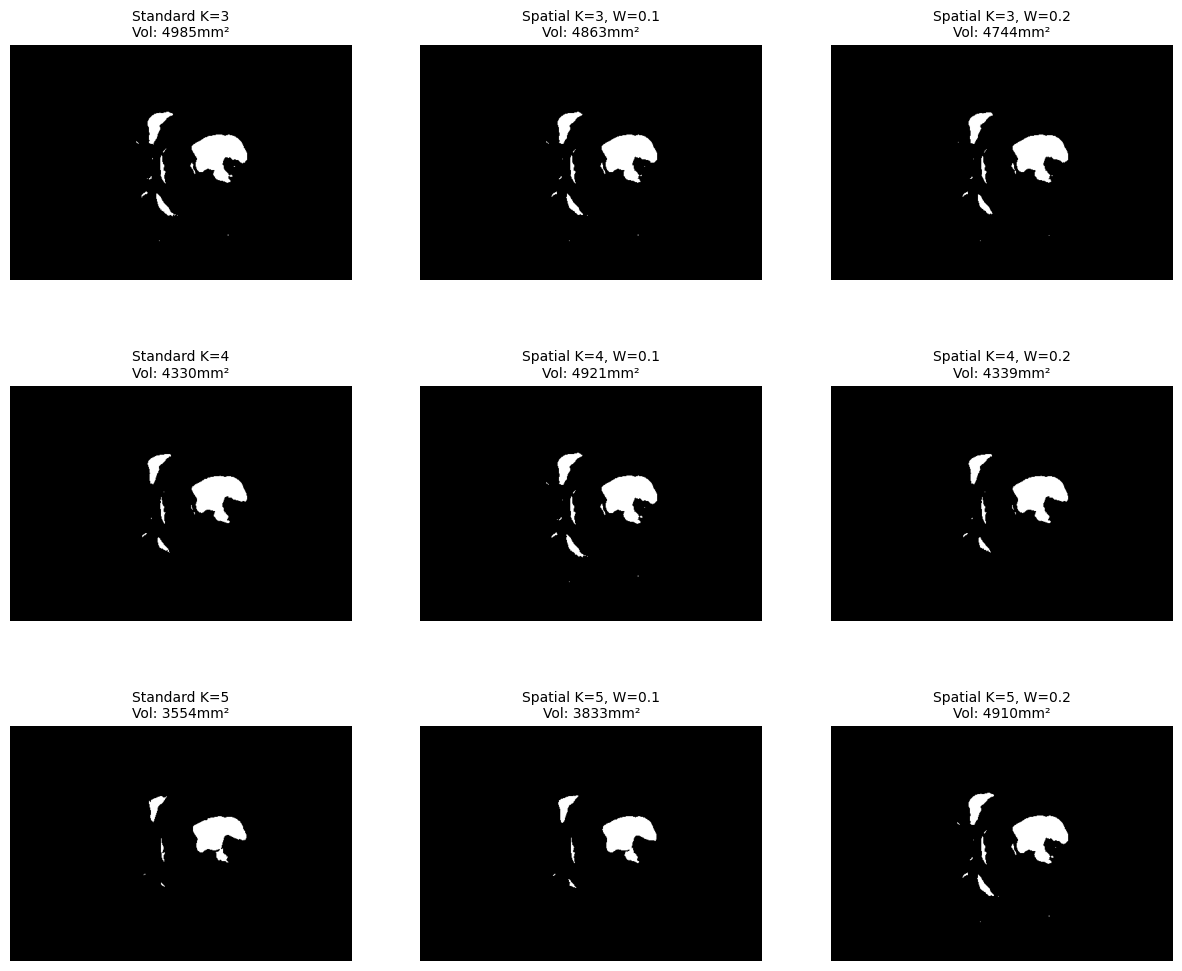

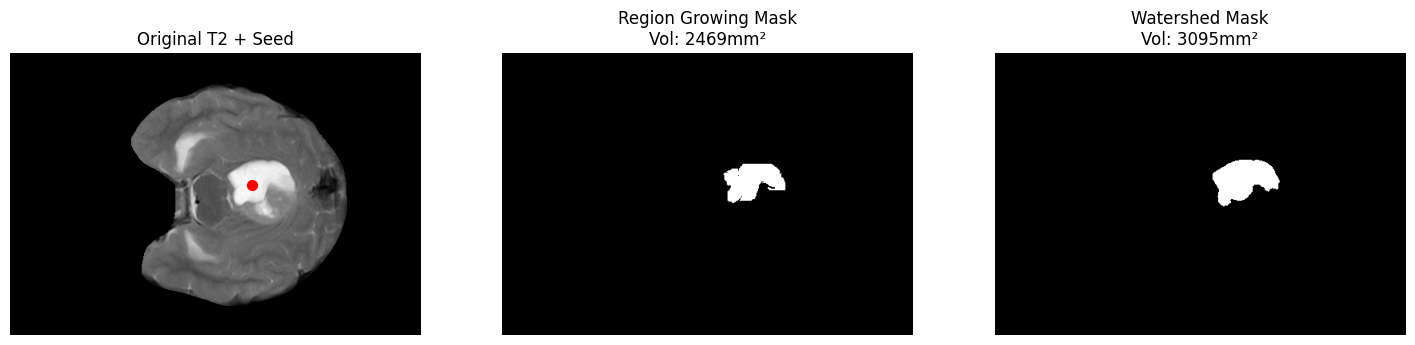

In [141]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# 全局变量
seed_point = None
img_t2 = None

def get_kmeans_mask(img, k, w_spatial, seed_x, seed_y):
    """手动实现改进 K-means：灰度 + 空间坐标"""
    h, w = img.shape
    y_idx, x_idx = np.indices((h, w))
    # 构建特征向量：[灰度, 归一化x*权重, 归一化y*权重]
    data = np.stack([
        img.flatten() / 255.0, 
        (x_idx.flatten() / w) * w_spatial, 
        (y_idx.flatten() / h) * w_spatial
    ], axis=1).astype(np.float32)
    
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
    _, labels, _ = cv2.kmeans(data, k, None, criteria, 10, cv2.KMEANS_PP_CENTERS)
    labels = labels.reshape((h, w))
    
    # 根据种子点坐标提取对应的聚类簇
    target_label = labels[seed_y, seed_x]
    mask = np.zeros_like(img)
    mask[labels == target_label] = 255
    return mask, labels

def main():
    global seed_point, img_t2
    if not os.path.exists('T2.npy'): return

    # 1. 预处理
    raw = np.load('T2.npy')
    img_t2 = cv2.normalize(raw, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    h, w = img_t2.shape

    # 2. 交互选取种子点
    print(">>> 请在弹出窗口点击病灶中心...")
    cv2.imshow("1. Click Lesion Center", img_t2)
    def on_click(event, x, y, flags, param):
        global seed_point
        if event == cv2.EVENT_LBUTTONDOWN:
            seed_point = (x, y)
            cv2.destroyWindow("1. Click Lesion Center")
    cv2.setMouseCallback("1. Click Lesion Center", on_click)
    cv2.waitKey(0)
    
    if seed_point is None: return
    sx, sy = seed_point

    # 3. 区域生长：带滑动条实时调优 (解决溢出问题)
    print(">>> 正在运行区域生长，请在弹出窗口通过滑动条调整容忍度 (Tolerance)...")
    cv2.namedWindow("2. Adjust Region Growing")
    cv2.createTrackbar("Tol", "2. Adjust Region Growing", 15, 50, lambda x: None)
    
    mask_rg = np.zeros_like(img_t2)
    while True:
        tol = cv2.getTrackbarPos("Tol", "2. Adjust Region Growing")
        # 调用库函数实现区域生长
        ff_mask = np.zeros((h + 2, w + 2), np.uint8)
        # flags: 填充值为 255，且只填充 mask
        flags = 4 | (255 << 8) | cv2.FLOODFILL_MASK_ONLY
        cv2.floodFill(img_t2, ff_mask, (sx, sy), 0, (tol,), (tol,), flags)
        mask_rg = ff_mask[1:-1, 1:-1]
        
        # 实时显示预览
        preview = cv2.cvtColor(img_t2, cv2.COLOR_GRAY2BGR)
        preview[mask_rg == 255] = [0, 0, 255] # 红色高亮生长区域
        cv2.imshow("2. Adjust Region Growing", preview)
        
        key = cv2.waitKey(1) & 0xFF
        if key == 13: # 按回车确认结果并继续
            cv2.destroyAllWindows()
            break

    # 4. 改进 K-Means 多参数对比测试 (K=3,4,5; Weight=0.0, 0.1, 0.2)
    print(">>> 正在进行 K-Means 多参数对比测试...")
    k_values = [3, 4, 5]
    weights = [0.0, 0.1, 0.2] # 0.0 即标准 K-means
    
    km_fig, km_axes = plt.subplots(len(k_values), len(weights), figsize=(15, 12))
    plt.subplots_adjust(hspace=0.4)
    
    for i, k in enumerate(k_values):
        for j, w_s in enumerate(weights):
            mask, _ = get_kmeans_mask(img_t2, k, w_s, sx, sy)
            vol = np.sum(mask == 255)
            
            km_axes[i, j].imshow(mask, cmap='gray')
            title = f"Standard K={k}" if w_s == 0 else f"Spatial K={k}, W={w_s}"
            km_axes[i, j].set_title(f"{title}\nVol: {vol}mm²", fontsize=10)
            km_axes[i, j].axis('off')

    # 5. 分水岭 (Watershed) 库函数调用
    _, brain_mask = cv2.threshold(img_t2, 20, 255, cv2.THRESH_BINARY)
    markers = np.zeros(img_t2.shape, dtype=np.int32)
    markers[brain_mask == 0] = 1 # 背景设为 1
    cv2.circle(markers, (sx, sy), 5, 2, -1) # 种子点设为 2
    
    gradient = cv2.morphologyEx(img_t2, cv2.MORPH_GRADIENT, np.ones((3,3)))
    cv2.watershed(cv2.cvtColor(gradient, cv2.COLOR_GRAY2BGR), markers)
    mask_water = np.zeros_like(img_t2)
    mask_water[markers == 2] = 255

    # 6. 最终综合展示图
    res_fig, res_axes = plt.subplots(1, 3, figsize=(18, 6))
    res_axes[0].imshow(img_t2, cmap='gray')
    res_axes[0].scatter(sx, sy, c='red', s=50, label='Seed')
    res_axes[0].set_title("Original T2 + Seed")
    
    res_axes[1].imshow(mask_rg, cmap='gray')
    res_axes[1].set_title(f"Region Growing Mask\nVol: {np.sum(mask_rg == 255)}mm²")
    
    res_axes[2].imshow(mask_water, cmap='gray')
    res_axes[2].set_title(f"Watershed Mask\nVol: {np.sum(mask_water == 255)}mm²")
    
    for ax in res_axes: ax.axis('off')
    
    print("\n[完成] 请查看对比图表。")
    plt.show()

if __name__ == "__main__":
    main()